<a href="https://colab.research.google.com/github/tiburon-blanco/herramientasCienciaDeDatos/blob/main/03_A_ClasificacionSVM_wine_Martin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NOTAS PARA ARMAR CLASE:
1. En el inicio poner texto introductorio al tema
1. En cada celda de código poner texto no solo explicando lo que hace sino mapeando con el proceso
1. Explicar los resultados o dejarlos como preguntas


## Aprendizaje Automático Avanzado - Support Vector Machine (SVM)

SVM ha resultado ser uno de los mejores clasificadores para un amplio abanico de situaciones, por lo que se considera uno de los referentes dentro del ámbito de machine learning.
SVM es un modelo de aprendizaje supervisado, por lo tanto requiere datos etiquetados. En el proceso de entrenamiento, el algoritmo analiza los datos de entrada y reconoce patrones en un espacio de características multidimensionales denominado hiperplano. Todos los ejemplos de entrada se representan como puntos en este espacio y se asignan a categorías de salida, de tal manera que las categorías se dividen de forma tan amplia y clara como sea posible.

El SVM genera un hiperplano óptimo de forma iterativa, que se utiliza para minimizar un error. La idea central de SVM es encontrar un hiperplano marginal máximo que mejor divida el conjunto de datos en clases ( en el caso que se use para clasificación).

Para esta práctica utilizaremos un conjunto de datos creado utilizando muestras de vino tinto y blanco. Las entradas incluyen pruebas objetivas (por ejemplo, valores de PH) y la salida se basa en datos sensoriales (mediana de al menos 3 evaluaciones realizadas por expertos en vinos). Cada experto calificó la calidad del vino entre 0 (muy mala) y 10 (muy excelente).


In [110]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import  metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

In [111]:
# Reemplaza 'ID_DEL_ARCHIVO' con el ID real de tu archivo CSV en Google Drive
dfwine = pd.read_csv('https://drive.google.com/uc?export=download&id=1bHynHqbg_yqiaotBldtdE9raRHGHyycc')
dfwine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.590,0.08,4.4,0.086,6.0,29.0,0.99740,3.38,0.50,9.0,4
1,5.7,1.130,0.09,1.5,0.172,7.0,19.0,0.99400,3.50,0.48,9.8,4
2,8.8,0.610,0.30,2.8,0.088,17.0,46.0,0.99760,3.26,0.51,9.3,4
3,4.6,0.520,0.15,2.1,0.054,8.0,65.0,0.99340,3.90,0.56,13.1,4
4,8.3,0.675,0.26,2.1,0.084,11.0,43.0,0.99760,3.31,0.53,9.2,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1922,6.4,0.530,0.09,3.9,0.123,14.0,31.0,0.99680,3.50,0.67,11.0,4
1923,6.2,0.785,0.00,2.1,0.060,6.0,13.0,0.99664,3.59,0.61,10.0,4
1924,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4
1925,5.6,0.620,0.03,1.5,0.080,6.0,13.0,0.99498,3.66,0.62,10.1,4


### Acceder a archivos desde Google Drive (para colaborar en equipo)

Para que tu equipo pueda acceder al archivo `wineq.csv` de forma persistente y colaborativa, la mejor práctica es almacenarlo en Google Drive. Cada miembro del equipo debe montar su Google Drive en Colab y luego acceder al archivo desde la ruta compartida.

In [112]:
# Montar Google Drive en Colab
from google.colab import drive
drive.mount('/content/drive')

# Después de montar Drive, puedes acceder al archivo si lo has guardado
# en una ruta como 'MyDrive/AA_UGR_Practicas/Datasets/wineq.csv'
# dfwine = pd.read_csv('/content/drive/MyDrive/AA_UGR_Practicas/Datasets/wineq.csv')
# display(dfwine.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## PREPROCESAMIENTO

Variables de entrada:

acidez fija

acidez volátil

ácido cítrico

azúcar residual

cloruros

dióxido de azufre libre

dióxido de azufre total

densidad

pH

sulfatos

alcohol


Variable de salida :

calidad (puntuación entre 0 y 10)

In [113]:
dfwine.isnull().sum().sort_values(ascending=False)

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [114]:
dfwine['quality'].value_counts()

,count
quality,
5,681
6,638
7,398
4,210


Veamos la información general del dataset

In [115]:
dfwine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1927 entries, 0 to 1926
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1927 non-null   float64
 1   volatile acidity      1927 non-null   float64
 2   citric acid           1927 non-null   float64
 3   residual sugar        1927 non-null   float64
 4   chlorides             1927 non-null   float64
 5   free sulfur dioxide   1927 non-null   float64
 6   total sulfur dioxide  1927 non-null   float64
 7   density               1927 non-null   float64
 8   pH                    1927 non-null   float64
 9   sulphates             1927 non-null   float64
 10  alcohol               1927 non-null   float64
 11  quality               1927 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 180.8 KB


In [116]:
dfwine['quality'].unique()

array([4, 5, 6, 7])

In [117]:

dfwine.shape
dfwine.describe()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000,1927.000000
mean,8.331136,0.527686,0.273290,2.570161,0.086621,15.447327,44.706279,0.996675,3.314624,0.661199,10.504939,5.635184
std,1.770878,0.187141,0.199192,1.442953,0.048763,10.365088,32.860156,0.001895,0.157037,0.176138,1.082208,0.929089
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,4.000000
25%,7.100000,0.380000,0.090000,1.900000,0.069000,7.000000,21.000000,0.995500,3.210000,0.550000,9.600000,5.000000
50%,8.000000,0.520000,0.260000,2.200000,0.079000,13.000000,36.000000,0.996680,3.310000,0.620000,10.300000,6.000000
75%,9.300000,0.640000,0.430000,2.600000,0.090000,21.000000,60.000000,0.997800,3.400000,0.740000,11.200000,6.000000
max,15.900000,1.330000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,7.000000


Según las conclusiones anteriores, se acotará el alcance del modelo a las clases de calidad 5, 6 y 7, filtrando el DataFrame `dfwine`.

In [118]:
# Filtrar el DataFrame para mantener solo las calidades 5, 6 y 7
dfwine = dfwine[dfwine['quality'].isin([5, 6, 7])]
display(dfwine['quality'].value_counts())
display(dfwine.head())

,count
quality,
5,681
6,638
7,398


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
53,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
54,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
55,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
56,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
57,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


## ANALISIS UNIVARIADO

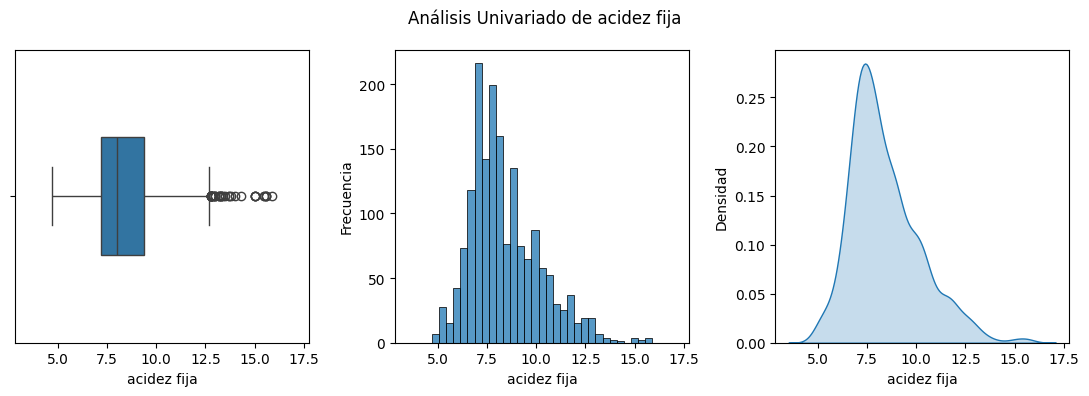

In [119]:
var = 'fixed acidity'
var_title = 'acidez fija'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de ' + var_title)

plt.tight_layout()

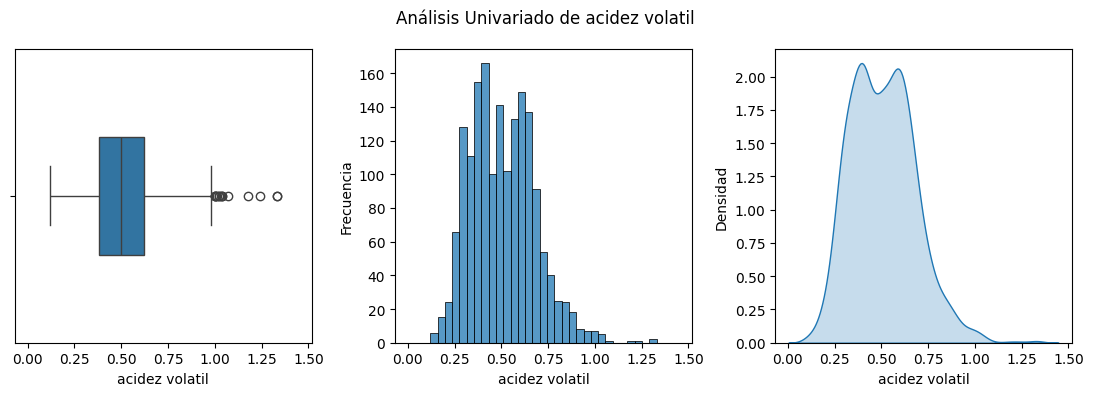

In [120]:

var = 'volatile acidity'
var_title = 'acidez volatil'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de ' + var_title)

plt.tight_layout()

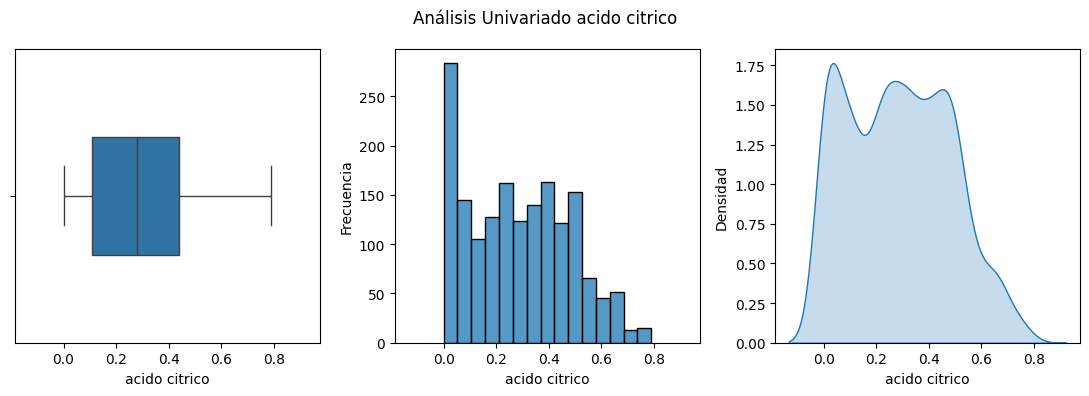

In [121]:
var = 'citric acid'
var_title = 'acido citrico'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado ' + var_title)

plt.tight_layout()

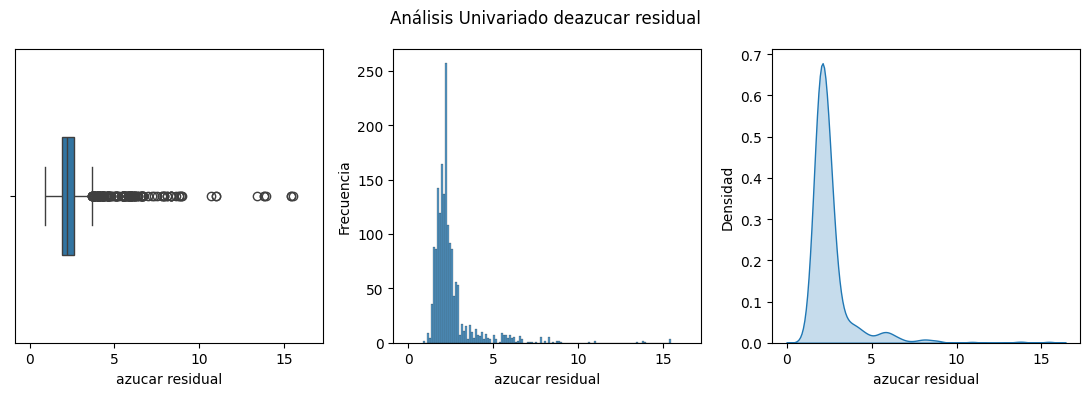

In [122]:
var = 'residual sugar'
var_title = 'azucar residual'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de' + var_title)

plt.tight_layout()

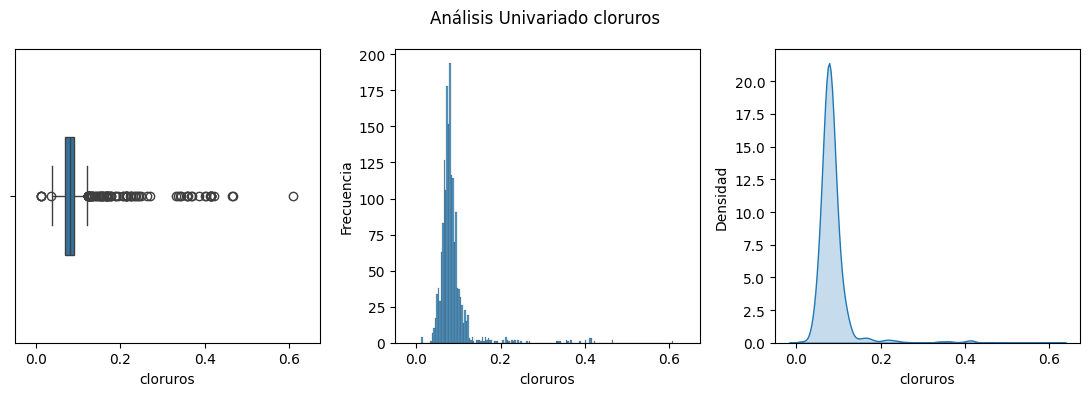

In [123]:
var = 'chlorides'
var_title = 'cloruros'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado ' + var_title)

plt.tight_layout()

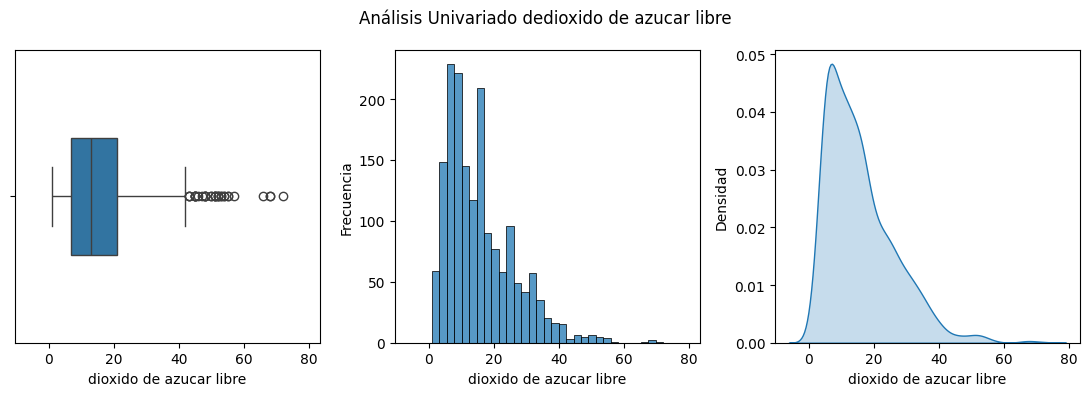

In [124]:
var = 'free sulfur dioxide'
var_title = 'dioxido de azucar libre'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de' + var_title)

plt.tight_layout()

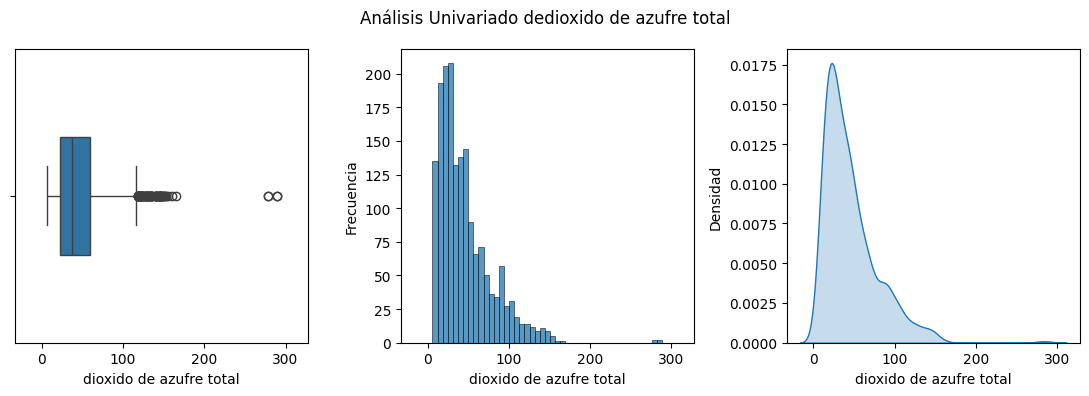

In [125]:
var = 'total sulfur dioxide'
var_title = 'dioxido de azufre total'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de' + var_title)

plt.tight_layout()

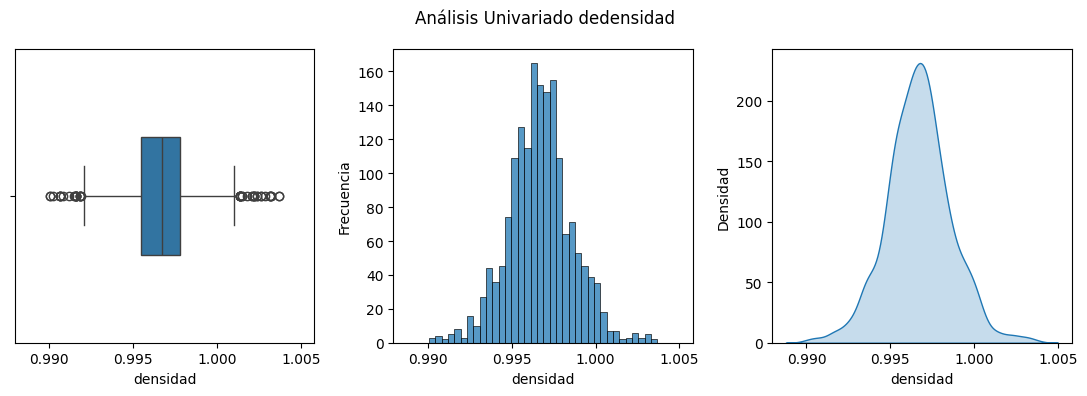

In [126]:
var = 'density'
var_title = 'densidad'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de' + var_title)

plt.tight_layout()

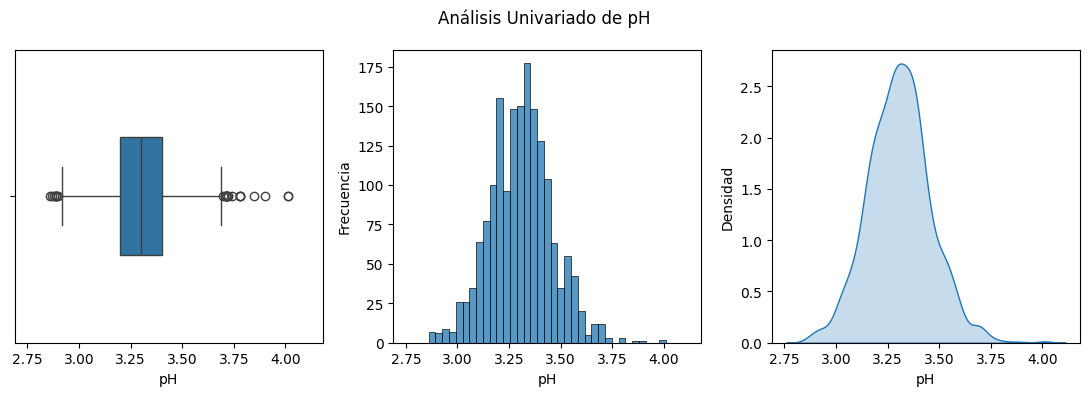

In [127]:
var = 'pH'
var_title = 'pH'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de ' + var_title)

plt.tight_layout()

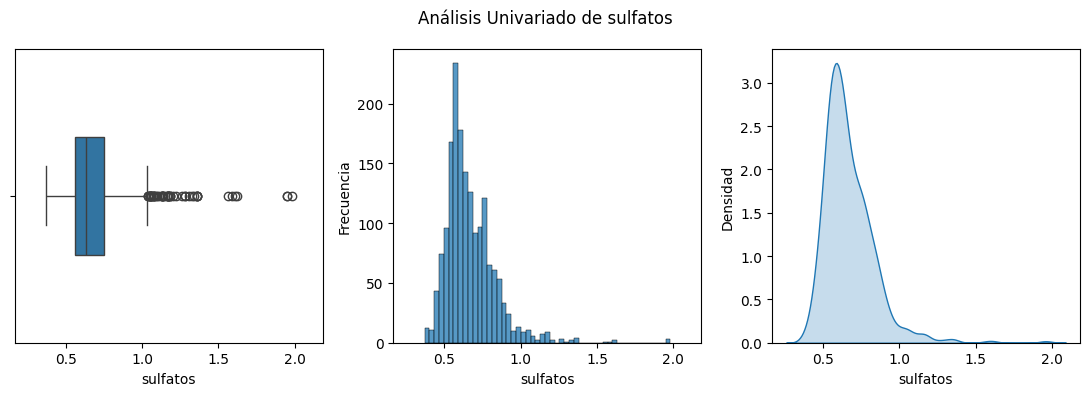

In [128]:
var = 'sulphates'
var_title = 'sulfatos'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de ' + var_title)

plt.tight_layout()

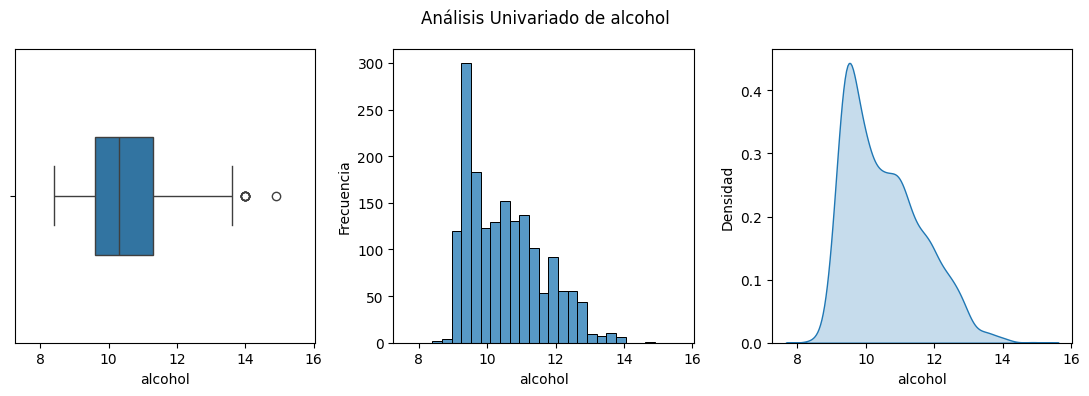

In [129]:
var = 'alcohol'
var_title = 'alcohol'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de ' + var_title)

plt.tight_layout()

In [ ]:
sns.pairplot(dfwine, hue="quality", diag_kind="kde")

Miramos la correlación de las variables


In [ ]:
X=dfwine.drop('quality', axis=1)

In [ ]:
variables_cuantitativas= X.columns
for var in variables_cuantitativas:
    grupos = [grupo[var].values for nombre, grupo in dfwine.groupby('quality')]
    f_stat, p_valor = stats.f_oneway(*grupos)
    print(f"ANOVA para {var}: F-statistic = {f_stat}, p-value = {p_valor}")



In [ ]:
correlation = X.corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation,vmax=1,square=True,annot=True,cmap='coolwarm')

In [ ]:
y=dfwine.quality
#X=dfwine['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar','chlorides','free sulfur dioxide', 'density', 'pH',  'sulphates', 'alcohol']         0
#dfwine.drop('total sulfur dioxide', axis=1, inplace=True)




Particionamos


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)



Escalamos los datos porque tienen dimensiones muy diferentes


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_array = sc.fit_transform(X_train.values)
X_train = pd.DataFrame(X_train_array, index=X_train.index, columns=X_train.columns)
X_test_array = sc.transform(X_test.values)
X_test = pd.DataFrame(X_test_array, index=X_test.index, columns=X_test.columns)


Ponemos a entrenar el modelo


In [ ]:
clf=SVC(kernel='rbf').fit(X_train,y_train)


In [ ]:
y_pred=clf.predict(X_test)

In [ ]:
mc_clf=confusion_matrix(y_test, y_pred) #Matriz de confusion con las etiquetas reales de Test y los valores predichos
mc_clf = metrics.ConfusionMatrixDisplay(confusion_matrix = mc_clf, display_labels = ['4', '5','6','7'] )
mc_clf.plot()
# Reporte de clasificación
print(classification_report(y_test, y_pred))

# Conclusiones
El modelo tiene un Accuracy del 0.64, podría ser aceptable por el contexto de aplicación.

Analizando la sensibilidad de cada una de las clases, podemos apreciar que tiene dificultades para encotrar las calidades 3, 4, y 8 que está desbalanceadas. La clase 7 la confundió bastante con la 6.

Quizas con un pre-procesamiento de las mismas, u obteniendo más instancias de esas clases mejoraría la calidad del modelo.

Otra posibilidad sería acotar el alcance del modelo a las clases 5,6 y 7


## 1- Desarrollo de la consigna

En esta sección se reduce el alcance del problema a las clases 5, 6 y 7 de la variable `quality`, con el objetivo de trabajar con las categorías más representativas y evitar que la clase 4, de menor frecuencia, introduzca un desbalance adicional.

Luego se entrena un modelo base con SVM, se ajustan hiperparámetros para mejorar el rendimiento y, como análisis extra, se estudia la presencia de outliers para evaluar si algún preprocesamiento puede ayudar a identificar mejor las clases minoritarias.

In [ ]:

dfwine = pd.read_csv("wineq.csv")
dfwine.head()

Paso 2 — Filtrar solo las clases 5, 6 y 7


In [ ]:
# Nos quedamos solo con las clases 5, 6 y 7
dfwine_567 = dfwine[dfwine["quality"].isin([5, 6, 7])].copy()

print("Dimensión original:", dfwine.shape)
print("Dimensión filtrada:", dfwine_567.shape)
print("\nDistribución de clases:")
print(dfwine_567["quality"].value_counts().sort_index())

### Interpretación del filtrado

Luego del filtrado, el dataset queda restringido a las clases 5, 6 y 7 de la variable `quality`. Esta decisión reduce el alcance del problema y elimina la clase 4, que presentaba menor frecuencia relativa.

De esta manera, el análisis se concentra en las categorías más representativas del conjunto de datos, lo que permite trabajar con un problema de clasificación más estable y con menor desbalance que el original.

Paso 3 — Ver la distribución de clases

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=dfwine_567, x="quality", order=[5, 6, 7])
plt.title("Distribución de clases después del filtrado")
plt.xlabel("Calidad")
plt.ylabel("Cantidad de vinos")
plt.show()

### Interpretación de la distribución de clases

La distribución de clases muestra que las categorías 5 y 6 son las más frecuentes, mientras que la clase 7 continúa siendo minoritaria respecto de las demás.

Esto implica que, si bien el filtrado redujo parte del desbalance, todavía existe una diferencia entre clases que puede afectar el desempeño del modelo, especialmente en la capacidad para identificar correctamente la clase 7.

### Paso 4 Separación entre variables predictoras y variable objetivo

Las variables fisicoquímicas del vino se utilizarán como entradas del modelo, mientras que la variable `quality` será la clase a predecir.

In [ ]:
X = dfwine_567.drop("quality", axis=1)
y = dfwine_567["quality"]

print("Cantidad de variables predictoras:", X.shape[1])
print("Clases objetivo:", sorted(y.unique()))

### Interpretación de la separación entre variables

Se definieron como variables predictoras todas las características fisicoquímicas del vino, mientras que la variable objetivo es `quality`.

Esto confirma que el problema a resolver es de clasificación supervisada multiclase, ya que el modelo deberá aprender a predecir una de tres categorías posibles: 5, 6 o 7.

Paso 5 — Partición train/test con estratificación

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nDistribución en y_train:")
print(y_train.value_counts().sort_index())
print("\nDistribución en y_test:")
print(y_test.value_counts().sort_index())
print(y_test.value_counts().sort_index())

### Interpretación de la partición de datos

La partición en conjuntos de entrenamiento y prueba se realizó utilizando estratificación, lo que permite conservar aproximadamente la misma proporción de clases en ambos subconjuntos.

Esto es importante porque evita que alguna clase quede subrepresentada en entrenamiento o en prueba, haciendo más confiable la evaluación posterior del modelo.

Paso 6 — Entrenar un modelo base con SVM

### Modelo base con SVM

Como primer punto de comparación se entrena un modelo SVM con kernel RBF y escalado estándar. Este modelo servirá como línea de base para luego evaluar si el ajuste de hiperparámetros mejora el desempeño.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

modelo_base = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_base), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_base), 4))
print("F1 macro:", round(f1_score(y_test, y_pred_base, average="macro"), 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred_base))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base)
plt.title("Matriz de confusión - Modelo base")
plt.show()

### Interpretación del modelo base

El modelo base con SVM y kernel RBF establece un punto de partida para el análisis. Las métricas obtenidas permiten medir el desempeño general antes de realizar ajustes más finos.

La métrica `accuracy` indica el porcentaje total de aciertos, mientras que `balanced accuracy` resulta especialmente útil en presencia de desbalance entre clases. Por su parte, `F1 macro` resume el rendimiento promedio del modelo considerando por igual a cada clase.

Este resultado servirá como referencia para comparar posteriormente si el ajuste de hiperparámetros mejora la capacidad de clasificación.

### Lectura del classification report

El reporte de clasificación muestra, para cada clase, las métricas de `precision`, `recall` y `f1-score`.

- `precision` indica cuán confiables son las predicciones de una clase.
- `recall` muestra qué proporción de los casos reales de esa clase logró detectar el modelo.
- `f1-score` resume el equilibrio entre ambas métricas.

En este problema, resulta especialmente relevante observar el comportamiento de la clase 7, ya que es una de las menos frecuentes y suele ser más difícil de identificar correctamente.

### Interpretación de la matriz de confusión

La matriz de confusión permite observar en qué clases acierta el modelo y entre cuáles tiende a confundirse.

Los valores de la diagonal principal representan las clasificaciones correctas, mientras que los restantes muestran errores de asignación entre clases. Este análisis es útil para detectar si el modelo distingue adecuadamente los vinos de calidad 5, 6 y 7, o si existen confusiones frecuentes entre categorías cercanas.

### PASO 7 Ajuste de hiperparámetros

Los hiperparámetros son valores que se definen antes del entrenamiento y controlan el comportamiento del modelo. En SVM, los más importantes son `C` y `gamma`.

- `C`: controla qué tan rígido o flexible es el margen de separación.
- `gamma`: controla cuánto influye cada observación en la frontera de decisión.
- `class_weight`: permite compensar el desbalance entre clases.

In [ ]:
from sklearn.model_selection import GridSearchCV

pipeline_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

param_grid = {
    "svm__kernel": ["rbf"],
    "svm__C": [0.1, 1, 5, 10, 20],
    "svm__gamma": ["scale", 0.01, 0.05, 0.1, 0.5],
    "svm__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid.best_params_)
print("\nMejor balanced accuracy en validación cruzada:")
print(round(grid.best_score_, 4))

### Interpretación del ajuste de hiperparámetros

La búsqueda en grilla permitió evaluar distintas combinaciones de hiperparámetros para identificar la configuración más conveniente del modelo SVM.

En particular:
- `C` controla la penalización por errores de clasificación;
- `gamma` regula la influencia de cada observación sobre la frontera de decisión;
- `class_weight` permite compensar el efecto del desbalance entre clases.

La mejor combinación encontrada será utilizada para entrenar un nuevo modelo y comparar si efectivamente mejora el desempeño respecto del modelo base.

## Paso 8 — Evaluar el mejor modelo ajustado

In [ ]:
mejor_modelo = grid.best_estimator_
y_pred_grid = mejor_modelo.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_grid), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_grid), 4))
print("F1 macro:", round(f1_score(y_test, y_pred_grid, average="macro"), 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred_grid))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_grid)
plt.title("Matriz de confusión - Mejor modelo ajustado")
plt.show()

### Interpretación del modelo ajustado

El modelo ajustado incorpora la mejor combinación de hiperparámetros encontrada mediante validación cruzada. Sus métricas deben compararse con las del modelo base para determinar si el ajuste produjo una mejora real.

Si `balanced accuracy` y `F1 macro` aumentan, puede considerarse que el ajuste permitió un mejor equilibrio en la clasificación de las distintas clases, especialmente en aquellas con menor representación.

Paso 9 — Comparar modelo base vs ajustado

In [ ]:
comparacion = pd.DataFrame([
    {
        "Modelo": "Base",
        "Accuracy": accuracy_score(y_test, y_pred_base),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_base),
        "F1 macro": f1_score(y_test, y_pred_base, average="macro")
    },
    {
        "Modelo": "Ajustado",
        "Accuracy": accuracy_score(y_test, y_pred_grid),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_grid),
        "F1 macro": f1_score(y_test, y_pred_grid, average="macro")
    }
])

comparacion.round(4)

### Comparación entre modelos

La tabla comparativa resume el rendimiento del modelo base y del modelo ajustado. Esta comparación permite verificar si la optimización de hiperparámetros generó mejoras en las métricas de interés.

En particular, se prioriza el análisis de `balanced accuracy` y `F1 macro`, ya que estas medidas ofrecen una visión más robusta del comportamiento del clasificador cuando las clases no están perfectamente balanceadas.

Paso 10 — Analizar outliers
### Análisis extra: detección de outliers

Se analiza la presencia de valores atípicos en las variables numéricas para evaluar si un preprocesamiento más robusto puede mejorar la identificación de las clases minoritarias, especialmente la clase 7.

In [ ]:
X_analisis = dfwine_567.drop("quality", axis=1)

Q1 = X_analisis.quantile(0.25)
Q3 = X_analisis.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_por_variable = ((X_analisis < limite_inferior) | (X_analisis > limite_superior)).sum()

tabla_outliers = pd.DataFrame({
    "Cantidad_outliers": outliers_por_variable,
    "Porcentaje": (outliers_por_variable / len(X_analisis) * 100).round(2)
}).sort_values("Cantidad_outliers", ascending=False)

tabla_outliers

### Interpretación del análisis de outliers

La tabla muestra cuántos valores atípicos presenta cada variable según el criterio del rango intercuartílico (IQR).

La presencia de outliers no implica necesariamente un error en los datos, ya que podrían corresponder a observaciones reales del proceso de producción del vino. Sin embargo, sí pueden influir en el comportamiento del modelo y en el escalado de las variables, por lo que resulta pertinente analizarlos antes de decidir un preprocesamiento.

Paso 11 — Ver boxplots de variables con más outliers

In [ ]:
variables_top = tabla_outliers.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(variables_top):
    sns.boxplot(data=dfwine_567, x="quality", y=var, ax=axes[i])
    axes[i].set_title(f"Boxplot de {var} por clase")

plt.tight_layout()
plt.show()

### Interpretación visual de los outliers

Los boxplots permiten observar la dispersión de cada variable según la clase y detectar visualmente valores extremos.

Este análisis resulta útil para evaluar si los outliers aparecen de manera aislada o si forman parte de la variabilidad natural de alguna clase. En caso de que los valores extremos sean consistentes con la estructura de los datos, puede ser preferible aplicar un escalado robusto antes que eliminar observaciones.

Paso 12 — Probar un preprocesamiento más robusto
### Decisión sobre preprocesamiento

Si bien existen outliers en varias variables, no conviene eliminarlos automáticamente porque podrían representar vinos reales y, además, la eliminación podría afectar más a las clases menos frecuentes.

Como alternativa, se prueba un escalado robusto (`RobustScaler`), que reduce la influencia de los valores extremos sin descartar observaciones.

In [ ]:
from sklearn.preprocessing import RobustScaler

modelo_robusto = Pipeline([
    ("scaler", RobustScaler()),
    ("svm", SVC(
        kernel=grid.best_params_["svm__kernel"],
        C=grid.best_params_["svm__C"],
        gamma=grid.best_params_["svm__gamma"],
        class_weight=grid.best_params_["svm__class_weight"]
    ))
])

modelo_robusto.fit(X_train, y_train)
y_pred_robusto = modelo_robusto.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_robusto), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_robusto), 4))
print("F1 macro:", round(f1_score(y_test, y_pred_robusto, average="macro"), 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred_robusto))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_robusto)
plt.title("Matriz de confusión - Modelo con RobustScaler")
plt.show()

### Interpretación del modelo con escalado robusto

El uso de `RobustScaler` busca reducir la influencia de los valores extremos sin eliminar observaciones del dataset. Esta estrategia puede ser especialmente útil cuando existen outliers pero no se desea perder información potencialmente relevante.

El desempeño de este modelo debe compararse con el modelo base y con el modelo ajustado para evaluar si el tratamiento robusto de las variables mejora la identificación de las clases menos representadas.

Paso 13 — Comparación final

In [ ]:
comparacion_final = pd.DataFrame([
    {
        "Modelo": "Base",
        "Accuracy": accuracy_score(y_test, y_pred_base),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_base),
        "F1 macro": f1_score(y_test, y_pred_base, average="macro")
    },
    {
        "Modelo": "Ajustado",
        "Accuracy": accuracy_score(y_test, y_pred_grid),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_grid),
        "F1 macro": f1_score(y_test, y_pred_grid, average="macro")
    },
    {
        "Modelo": "Ajustado + RobustScaler",
        "Accuracy": accuracy_score(y_test, y_pred_robusto),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_robusto),
        "F1 macro": f1_score(y_test, y_pred_robusto, average="macro")
    }
])

comparacion_final.round(4)

### Interpretación de la comparación final

La comparación final permite determinar cuál de los enfoques ensayados ofrece el mejor equilibrio entre precisión global y capacidad de clasificación por clase.

Si el modelo ajustado con o sin `RobustScaler` supera al modelo base en `balanced accuracy` y `F1 macro`, puede concluirse que el ajuste de hiperparámetros y/o el tratamiento robusto de outliers aportaron una mejora en el rendimiento del clasificador.

Paso 14 — Conclusión final

## Conclusión de la consigna

Al reducir el problema a las clases 5, 6 y 7 se obtuvo un conjunto más estable para la clasificación. El modelo base con SVM permitió establecer una referencia inicial, mientras que el ajuste de hiperparámetros mejoró el rendimiento, especialmente en métricas más sensibles al desbalance como `balanced accuracy` y `F1 macro`.

En el análisis extra se observó la presencia de outliers en varias variables. Sin embargo, en lugar de eliminarlos, se decidió probar un escalado robusto, ya que esta estrategia conserva las observaciones y reduce la influencia de valores extremos. Esto resulta más apropiado cuando se busca no perjudicar la identificación de clases minoritarias.